In [15]:
# Базовые библиотеки
import os
import sys
import math
import time
import random
from typing import Tuple, Dict, List
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import datasets, transforms

from torchvision.models import resnet18, ResNet18_Weights

print("python:", sys.version)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

python: 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]
torch: 2.11.0+cu130
torchvision: 0.26.0+cu130


In [16]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [17]:
import kagglehub

DATASET_NAME = "paultimothymooney/chest-xray-pneumonia"

# Download latest version

DATASET_DIR = '../data/dataset'
kagglehub.dataset_download(DATASET_NAME, output_dir=DATASET_DIR)

print("Path to dataset files:", DATASET_DIR)

Path to dataset files: ../data/dataset


In [20]:
IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])


train_ds = datasets.ImageFolder(
    root=f"{DATASET_DIR}/chest_xray/train",
    transform=train_tf
)

val_ds = datasets.ImageFolder(
    root=f"{DATASET_DIR}/chest_xray/val",
    transform=eval_tf
)

test_ds = datasets.ImageFolder(
    root=f"{DATASET_DIR}/chest_xray/test",
    transform=eval_tf
)

In [28]:
print("Length of train split:", len(train_ds))
print("Lenght of val split:", len(val_ds))
print("Lenght of test split:", len(test_ds))

print("Name classes:", train_ds.classes)

Length of train split: 5216
Lenght of val split: 16
Lenght of test split: 624
Name classes: ['NORMAL', 'PNEUMONIA']


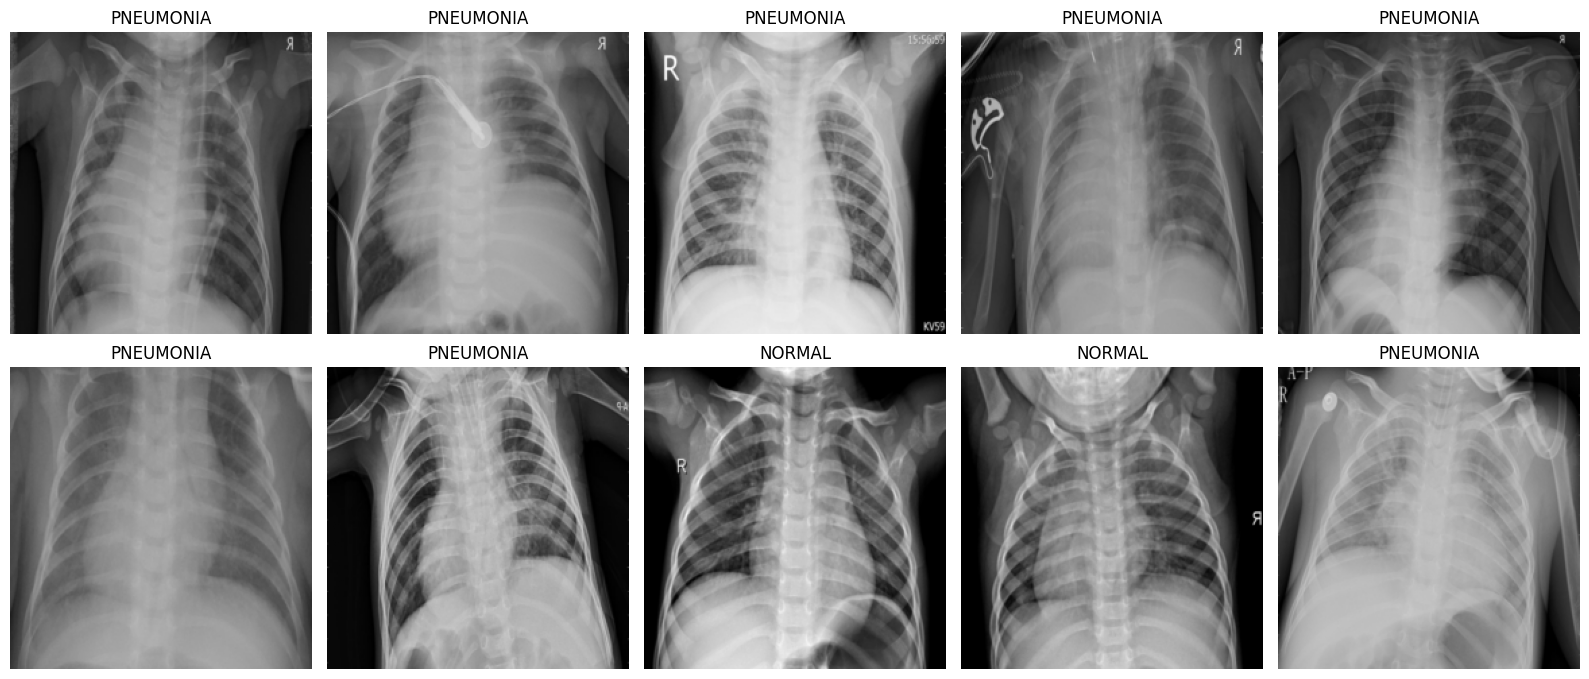

In [26]:
# показать 10 случайных снимков
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for ax in axes.flatten():
    idx = random.randint(0, len(train_ds) - 1)

    img, label = train_ds[idx]

    # Tensor -> numpy
    img = img.permute(1, 2, 0).numpy()

    # если grayscale канал один
    if img.shape[2] == 1:
        img = img.squeeze()
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)

    ax.set_title(train_ds.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

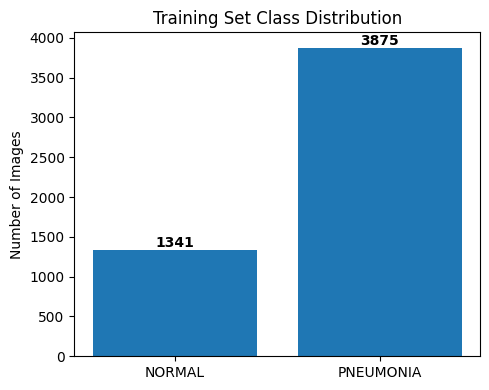

Imbalance ratio — Pneumonia : Normal = 2.89 : 1


In [31]:
normal_count    = len(os.listdir(os.path.join(f"{DATASET_DIR}/chest_xray/train", "NORMAL")))
pneumonia_count = len(os.listdir(os.path.join(f"{DATASET_DIR}/chest_xray/train", "PNEUMONIA")))

plt.figure(figsize=(5, 4))
plt.bar(["NORMAL", "PNEUMONIA"], [normal_count, pneumonia_count],)
        #color=["steelblue", "tomato"])
plt.title("Training Set Class Distribution")
plt.ylabel("Number of Images")
for i, v in enumerate([normal_count, pneumonia_count]):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Imbalance ratio — Pneumonia : Normal = {pneumonia_count/normal_count:.2f} : 1")